# Open the Door with a Mobile Arm

This notebook plans the `MobileArmDoor2D` example end-to-end. We hand the planner a single goal — "the door's handle is at this world point, which corresponds to the door being open at 90°" — and the BFS planner figures out the rest:

1. From the initial mode (door pinned to the world, no hinge yet), the goal isn't reachable.
2. The planner tries the bundled `attach_transition`. Its trigger is "arm tip at door handle", which the planner *can* reach by driving the mobile base toward the door and aiming the arm.
3. Applying the transition swaps in a `HingeJoint2D` (so the door can swing) and a `PointEquality2D` grip (so the arm holds the handle). In the resulting mode the goal *is* reachable: the planner drives the joints (and thereby the hinge angle) to put the handle at the target.

We don't tell the planner about the transition or the hinge. One `planner.plan(...)` call returns a trajectory that does it all.

In [1]:
import math

import numpy as np
from IPython.display import HTML
from matplotlib import animation, pyplot

from comb.constraints import ConstraintParameters, PointEquality2D
from comb.examples.mobile_arm_door_2d import MobileArmDoor2D
from comb.planners.stepping import SteppingPlanner
from comb.rendering.matplotlib_2d import MatplotlibRenderer2D
from comb.rendering.overlays import PointMarker2D

## 1. Build the scene

`MobileArmDoor2D` packages: an anchored world, a mobile base on a `PlanarJoint2D`, a 2-link arm on the base, and a door pinned to the world via a `FixedJoint2D` (no hinge yet). `ex.system.transitions` includes the `attach_transition` that fires when the arm tip reaches the door handle.

In [2]:
ex = MobileArmDoor2D()
hinge_x, hinge_y = ex.hinge_origin
print(f"Hinge at ({hinge_x}, {hinge_y}), door length {ex.door_length}")

Hinge at (2.0, 0.0), door length 1.0


## 2. Express the goal

The goal is "the door is open at 90° from its closed pose." That's equivalent to "the door's handle (at offset `(door_length, 0)` in the door's frame) is at the world point obtained by rotating the closed-pose handle around the hinge by 90°." Use a `PointEquality2D` to capture it.

In [3]:
target_angle = math.pi / 2

target_handle_x = hinge_x + ex.door_length * math.cos(target_angle)
target_handle_y = hinge_y + ex.door_length * math.sin(target_angle)
print(f"Target handle position: ({target_handle_x:.2f}, {target_handle_y:.2f})")

goal = PointEquality2D(
    body1=ex.world,
    body2=ex.door,
    fixed_parameters=ConstraintParameters(
        values=np.array([target_handle_x, target_handle_y, ex.door_length, 0.0]),
        names=PointEquality2D.fixed_parameter_names(),
    ),
)

Target handle position: (2.00, 1.00)


## 3. Plan

`SteppingPlanner.plan(ex.system, [goal], horizon=...)` does a BFS over modes. From the initial mode the goal is unreachable (door pinned), so the planner tries the attach transition, finds its trigger reachable, applies it, and from the resulting mode (hinge + grip) drives all parameters consistently to satisfy the goal.

In [ ]:
planner = SteppingPlanner(interval=0.15)
trajectory = planner.plan(ex.system, [goal], horizon=2.5).trajectory

end_state = trajectory(trajectory.duration)
final_handle_world = end_state.body_poses[ex.door].t + ex.door_length * np.array(
    [
        math.cos(end_state.body_poses[ex.door].theta()),
        math.sin(end_state.body_poses[ex.door].theta()),
    ]
)
print(f"Trajectory duration: {trajectory.duration:g} s")
print(
    f"Final handle position: ({final_handle_world[0]:.3f}, {final_handle_world[1]:.3f})"
)
print(f"Final door angle: {end_state.body_poses[ex.door].theta():.3f} rad")

## 4. Animate

Sample the trajectory and render each frame onto a single matplotlib axes. A `PointMarker2D` star shows the target handle position; the door's actual handle should sweep to coincide with it.

ValueError: interpolate_constraint_configuration requires matching constraint sets in start and end

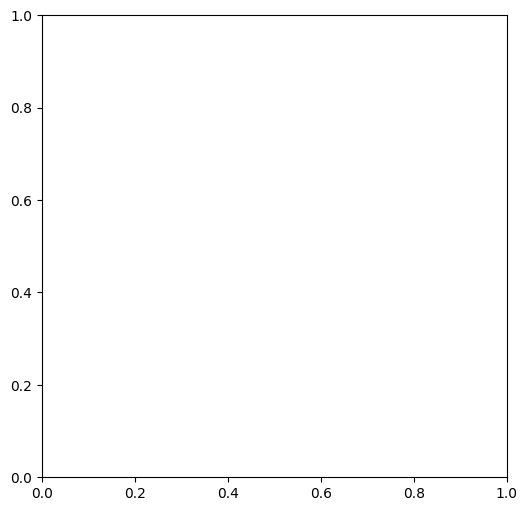

In [5]:
fig, ax = pyplot.subplots(figsize=(6, 6))
renderer = MatplotlibRenderer2D(ax=ax, xlim=(-1.0, 4.0), ylim=(-1.0, 2.5))

samples = list(trajectory.enumerate(0.05))
target_marker = PointMarker2D(
    x=target_handle_x,
    y=target_handle_y,
    marker="*",
    color="tab:orange",
    size=300.0,
)


def draw(frame_idx: int):
    _, state = samples[frame_idx]
    for body in ex.mode.bodies:
        ex.mode.body_poses[body] = state.body_poses[body]
    for c in ex.mode.configuration:
        ex.mode.configuration[c] = state.configuration[c]
    renderer.render(ex.mode, overlays=[target_marker])
    return []


anim = animation.FuncAnimation(fig, draw, frames=len(samples), interval=50)
pyplot.close(fig)
HTML(anim.to_jshtml())

## What to try next

- Change `target_angle` to a different value (e.g. `math.pi / 3`) and replay.
- Move the hinge origin (`hinge_origin=...` to `MobileArmDoor2D`) and see the planner adapt the approach + attach + swing path.
- Tighten / loosen `interval` and observe trajectory smoothness.